In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import colorcet as cc
import warnings
import re
import random

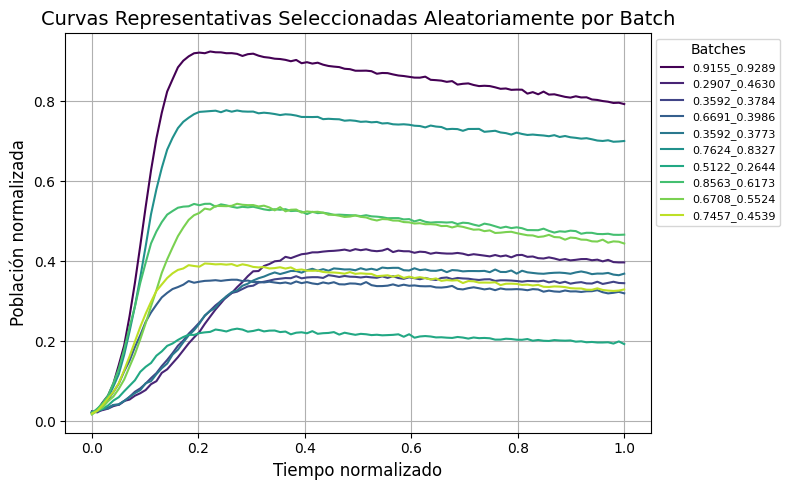

Combinaciones de efectos de drogas:
Tipo 1: Drug 1 Effect = 0.5122, Drug 2 Effect = 0.2644
Tipo 2: Drug 1 Effect = 0.9155, Drug 2 Effect = 0.9289
Tipo 3: Drug 1 Effect = 0.7624, Drug 2 Effect = 0.8327
Tipo 4: Drug 1 Effect = 0.6691, Drug 2 Effect = 0.3986
Tipo 5: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3773
Tipo 6: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3784
Tipo 7: Drug 1 Effect = 0.2907, Drug 2 Effect = 0.4630
Tipo 8: Drug 1 Effect = 0.8563, Drug 2 Effect = 0.6173
Tipo 9: Drug 1 Effect = 0.6708, Drug 2 Effect = 0.5524
Tipo 10: Drug 1 Effect = 0.7457, Drug 2 Effect = 0.4539


In [22]:
# Parámetros generales del modelo logístico
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos

# Generar 15 combinaciones aleatorias de drug_1_effect y drug_2_effect entre 0.25 y 1.0
np.random.seed(42)  # Fijar semilla para reproducibilidad
num_types = 10
curves_per_type = 100

# Generar combinaciones aleatorias de efectos de drogas
drug_1_effect_combinations = np.random.uniform(0.25, 0.95, num_types)
drug_2_effect_combinations = np.random.uniform(0.25, 0.95, num_types)

# Guardar las combinaciones en un vector claro
drug_effects_combinations = list(zip(drug_1_effect_combinations, drug_2_effect_combinations))

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

# Crear listas para almacenar las curvas y los batches
curves_list = []
batches_list = []

# Generar curvas y batches
for drug_1_effect, drug_2_effect in drug_effects_combinations:
    # Crear un batch name
    batch_name = f"{drug_1_effect:.4f}_{drug_2_effect:.4f}"

    for _ in range(curves_per_type):
        # Aplicar efectos de drogas
        r_drug = r * drug_1_effect + np.random.normal(0, 0.05 * r * drug_1_effect )   #10% de variación experimental aleatoria en r y K, de esta manera llega a 2 sigmas casi toda la distribucion
        K_drug = K * drug_2_effect + np.random.normal(0, 0.05 * K * drug_2_effect )
        decay_rate = decay_rate + np.random.normal(0, 0.05 * decay_rate)
        
        # Calcular la curva
        P_t_decay = logistic_growth_decay(t, K_drug, P0, r_drug, decay_rate)

        # Añadir ruido aleatorio a la curva
        noise = np.random.normal(0, 1.0, size=P_t_decay.shape)  # Ruido con desviación estándar 1.0
        P_t_decay_noisy = P_t_decay + noise

        # Normalizar la curva
        P_t_decay_norm_noisy = P_t_decay_noisy / K

        # Almacenar la curva y el batch en las listas
        curves_list.append(P_t_decay_norm_noisy)
        batches_list.append(batch_name)

# Convertir las listas en un DataFrame
df_curves = pd.DataFrame(curves_list).T

# Seleccionar una curva aleatoria de cada batch para graficar
random_indices = [np.random.choice([i for i, b in enumerate(batches_list) if b == batch_name]) for batch_name in set(batches_list)]

# Graficar las curvas seleccionadas
plt.figure(figsize=(8, 5))
for idx in random_indices:
    curve = df_curves[idx]
    batch_name = batches_list[idx]
    plt.plot(
        t / t[-1],
        curve,
        label=batch_name,
        color=plt.cm.viridis(random_indices.index(idx) / len(random_indices))
    )

# Configuración del gráfico
plt.title("Curvas Representativas Seleccionadas Aleatoriamente por Batch", fontsize=14)
plt.xlabel("Tiempo normalizado", fontsize=12)
plt.ylabel("Población normalizada", fontsize=12)
plt.legend(title="Batches", fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()
plt.tight_layout()
plt.show()

# Mostrar el DataFrame y la lista de batches
print("Combinaciones de efectos de drogas:")
for idx, (drug1, drug2) in enumerate(drug_effects_combinations, 1):
    print(f"Tipo {idx}: Drug 1 Effect = {drug1:.4f}, Drug 2 Effect = {drug2:.4f}")



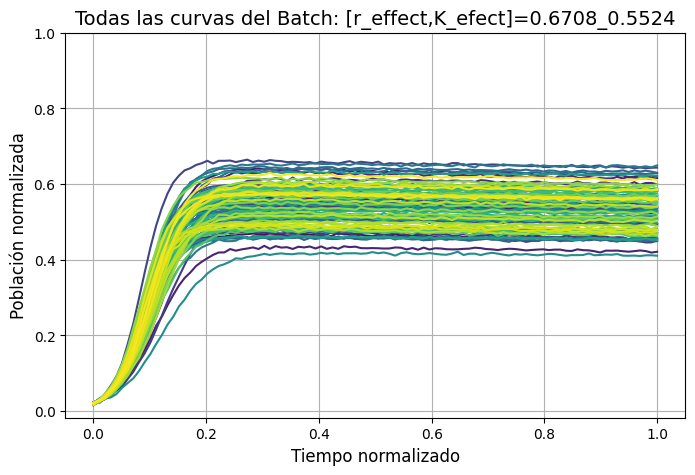

Combinaciones de efectos de drogas:
Tipo 1: Drug 1 Effect = 0.5122, Drug 2 Effect = 0.2644
Tipo 2: Drug 1 Effect = 0.9155, Drug 2 Effect = 0.9289
Tipo 3: Drug 1 Effect = 0.7624, Drug 2 Effect = 0.8327
Tipo 4: Drug 1 Effect = 0.6691, Drug 2 Effect = 0.3986
Tipo 5: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3773
Tipo 6: Drug 1 Effect = 0.3592, Drug 2 Effect = 0.3784
Tipo 7: Drug 1 Effect = 0.2907, Drug 2 Effect = 0.4630
Tipo 8: Drug 1 Effect = 0.8563, Drug 2 Effect = 0.6173
Tipo 9: Drug 1 Effect = 0.6708, Drug 2 Effect = 0.5524
Tipo 10: Drug 1 Effect = 0.7457, Drug 2 Effect = 0.4539


In [23]:
# Parámetros generales del modelo logístico
K = 500     # Capacidad de carga
P0 = 10     # Población inicial
r = 1.0     # Tasa de crecimiento
decay_rate = 0.005  # Tasa de decaimiento
t = np.linspace(0, 50, 100)  # Tiempo con 100 puntos

# Generar 15 combinaciones aleatorias de drug_1_effect y drug_2_effect entre 0.25 y 1.0
np.random.seed(42)  # Fijar semilla para reproducibilidad
num_types = 10
curves_per_type = 100

# Generar combinaciones aleatorias de efectos de drogas
drug_1_effect_combinations = np.random.uniform(0.25, 0.95, num_types)
drug_2_effect_combinations = np.random.uniform(0.25, 0.95, num_types)

# Guardar las combinaciones en un vector claro
drug_effects_combinations = list(zip(drug_1_effect_combinations, drug_2_effect_combinations))

# Función de crecimiento logístico con decay rate
def logistic_growth_decay(t, K, P0, r, decay_rate):
    logistic = K / (1 + ((K - P0) / P0) * np.exp(-r * t))
    return logistic * np.exp(-decay_rate * t)  # Aplicar decaimiento exponencial

# Crear listas para almacenar las curvas y los batches
curves_list = []
batches_list = []
conditions = []

# Generar curvas y batches
for drug_1_effect, drug_2_effect in drug_effects_combinations:
    # Crear un batch name
    batch_name = f"{drug_1_effect:.4f}_{drug_2_effect:.4f}"
    for _ in range(curves_per_type):
        # Aplicar efectos de drogas
        r_drug = r * drug_1_effect + np.random.normal(0, 0.1 * r * drug_1_effect)   #10% de variación experimental aleatoria en r y K, de esta manera llega a 2 sigmas casi toda la distribucion
        K_drug = K * drug_2_effect + np.random.normal(0, 0.1 * K * drug_2_effect)
        decay_rate = decay_rate + np.random.normal(0, 0.1 * decay_rate)
        # Calcular la curva
        P_t_decay = logistic_growth_decay(t, K_drug, P0, r_drug, decay_rate)

        # Añadir ruido aleatorio a la curva
        noise = np.random.normal(0, 1.0, size=P_t_decay.shape)  # Ruido con desviación estándar 1.0
        P_t_decay_noisy = P_t_decay + noise

        # Normalizar la curva
        P_t_decay_norm_noisy = P_t_decay_noisy / K

        # Almacenar la curva y el batch en las listas
        curves_list.append(P_t_decay_norm_noisy)
        batches_list.append(batch_name)
        conditions.append([drug_1_effect,drug_2_effect])


# Convertir las listas en un DataFrame
df_curves = pd.DataFrame(curves_list).T
C_curves = pd.DataFrame(conditions)
graphed_batch=-2

# Seleccionar un batch entero para graficar
unique_batches = list(set(batches_list))
curves_indices = [i for i, b in enumerate(batches_list) if b == unique_batches[graphed_batch]]     #AQUI se mearca que curvas graficar para poder ver la variabilidad generada, en función de unique_batches

# Graficar las curvas seleccionadas
plt.figure(figsize=(8, 5))
for idx in curves_indices:
    curve = df_curves[idx]
    batch_name = idx
    plt.plot(
        t / t[-1],
        curve,
        label=batch_name,
        color=plt.cm.viridis(curves_indices.index(idx) / len(curves_indices))
    )

# Configuración del gráfico
plt.title(f"Todas las curvas del Batch: [r_effect,K_efect]={unique_batches[graphed_batch]}", fontsize=14)
plt.xlabel("Tiempo normalizado", fontsize=12)
plt.ylabel("Población normalizada", fontsize=12)
#plt.legend(title="Batches", fontsize=8, loc="upper left", bbox_to_anchor=(1, 1))
plt.grid()
plt.yticks(np.arange(0, 1.01, 0.2)) 
#plt.tight_layout()
plt.show()

# Mostrar el DataFrame y la lista de batches
print("Combinaciones de efectos de drogas:")
for idx, (drug1, drug2) in enumerate(drug_effects_combinations, 1):
    print(f"Tipo {idx}: Drug 1 Effect = {drug1:.4f}, Drug 2 Effect = {drug2:.4f}")


In [25]:
random.seed(2)
# Crear una lista única de los batches para identificar los tipos
unique_batches = list(set(batches_list))

# Inicializar listas para índices de train y test
test_indices = []
train_indices = []

# Calcular el porcentaje para cada tipo
for batch in unique_batches:
    # Obtener los índices de las curvas asociadas a este batch
    batch_indices = [i for i, b in enumerate(batches_list) if b == batch]
    num_test = int(len(batch_indices) * 0.2)  # 20% para test

    # Barajar los índices y dividir en test y train
    random.shuffle(batch_indices)
    test_indices.extend(batch_indices[:num_test])
    train_indices.extend(batch_indices[num_test:])

# Crear DataFrames y listas de batches para train y test
df_train = df_curves.iloc[:,train_indices].copy()
df_test = df_curves.iloc[:,test_indices].copy()

batches_train = [batches_list[i] for i in train_indices]
batches_test = [batches_list[i] for i in test_indices]

print(f"Número de curvas en train: {len(batches_train)}")
print(f"Número de curvas en test: {len(batches_test)}")
print(f"Distribución en test por tipo: {pd.Series(batches_test).value_counts()}")
print(f"Distribución en train por tipo: {pd.Series(batches_train).value_counts()}")


Número de curvas en train: 800
Número de curvas en test: 200
Distribución en test por tipo: 0.9155_0.9289    20
0.2907_0.4630    20
0.3592_0.3784    20
0.6691_0.3986    20
0.3592_0.3773    20
0.7624_0.8327    20
0.5122_0.2644    20
0.8563_0.6173    20
0.6708_0.5524    20
0.7457_0.4539    20
Name: count, dtype: int64
Distribución en train por tipo: 0.9155_0.9289    80
0.2907_0.4630    80
0.3592_0.3784    80
0.6691_0.3986    80
0.3592_0.3773    80
0.7624_0.8327    80
0.5122_0.2644    80
0.8563_0.6173    80
0.6708_0.5524    80
0.7457_0.4539    80
Name: count, dtype: int64


In [26]:
class robust_VAE(nn.Module):
    def __init__(self, input_dim, latent_dim, num_hidden_layers, hidden_dims):
        super(robust_VAE, self).__init__()
        
        # Construct the encoder
        encoder_layers = []
        prev_dim = input_dim
        for i in range(num_hidden_layers):
            encoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            encoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Mean and log variance layers
        self.mean_layer = nn.Linear(hidden_dims[-1], latent_dim)
        self.logvar_layer = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Construct the decoder
        decoder_layers = []
        prev_dim = latent_dim
        for i in reversed(range(num_hidden_layers)):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dims[i]))
            decoder_layers.append(nn.Sigmoid())
            prev_dim = hidden_dims[i]
        
        decoder_layers.append(nn.Linear(hidden_dims[0], input_dim))
        
        self.decoder = nn.Sequential(*decoder_layers)
        
    def encode(self, x):
        x = self.encoder(x)
        mean, logvar = self.mean_layer(x), self.logvar_layer(x)
        return mean, logvar

    def reparameterization(self, mean, logvar):
        epsilon = torch.randn_like(logvar)   
        z = mean + torch.exp(logvar * 0.5) * epsilon   
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, logvar = self.encode(x)
        z = self.reparameterization(mean, logvar)
        x_hat = self.decode(z)
        return x_hat, mean, logvar

def loss_function(x, x_hat, mean, log_var,alpha):
    reproduction_loss =nn.MSELoss()(x,x_hat)
    KLD = (- 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp()))/(x.shape[0])
    aux=reproduction_loss.detach().numpy()
    return reproduction_loss + alpha*KLD,aux

In [17]:
df_train_T=df_train.T
df_test_T=df_test.T
X_train=df_train_T.values
X_test=df_test_T.values
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)

custom_palette=sns.color_palette(cc.glasbey,len(batches_test)) 

In [18]:
torch.manual_seed(42)
trained_models = []

input_dim = X_train.shape[1]  # Number of input features
latent_dim = 2  # Desired number of output dimensions
num_hidden_layers=2
hidden_layers=[48,16]      #From bigger to smaller
model = robust_VAE(input_dim, latent_dim,num_hidden_layers,hidden_layers)
alpha=5E-5  #5E-5 
str_alpha="{:.0E}".format(alpha)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=5E-3)     #Optimizer algorithm, lr: learning rate 5E-3

# Training the autoencoder
num_epochs = 10000          #Number of 'jumps' 15000
train_losses = []
test_losses = []
mse_test=0
for epoch in range(num_epochs):
   # Training phase
   x_hat, mean, log_var = model(X_train_tensor)            # Forward pass
   train_loss,_ = loss_function(X_train_tensor, x_hat, mean, log_var,alpha)

   # Backward pass and optimization, in fact this is the training of the parameters of the model
   optimizer.zero_grad()         #In this way the gradient is not cumulative
   train_loss.backward()             #The gradients (derivatives) of the parameters to optimize (points of the growth) 
   optimizer.step()              #Actualize the optimizer(do the step of the optimizer), in the case of the Adam it multiplies the new vector by the lr

   train_losses.append(train_loss.item())  # Append train loss
   
   with torch.no_grad():  # Disable gradient calculation for the test evaluation
      x_hat, mean, log_var = model(X_test_tensor)            # Forward pass
      test_loss,mse_test = loss_function(X_test_tensor, x_hat, mean, log_var,alpha)
   print(test_loss.detach().numpy(),mse_test)
   test_losses.append(test_loss.item())  # Append test loss
trained_models.append(model)
#torch.save(model.state_dict(), 'saved_models/VAE_n1000_alpha{str_alpha[0]}E{str_alpha[4]}lr5E4_v3.pth')
print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')

0.20895816 0.20895714
0.13693534 0.1369323
0.090200916 0.09019494
0.06336448 0.06335484
0.05062898 0.050615303
0.0471557 0.047138013
0.04916929 0.04914796
0.052734226 0.05270963
0.05581227 0.0557847
0.057679396 0.057648912
0.057443503 0.057410084
0.056005724 0.05596918
0.05328889 0.053249013
0.05016678 0.050123256
0.046857003 0.0468096
0.04422023 0.044168897
0.041643616 0.041588396
0.04005523 0.03999635
0.038916025 0.038853697
0.038175885 0.038110547
0.038095567 0.038027763
0.037902057 0.03783244
0.037737213 0.03766628
0.037724957 0.037653305
0.037326336 0.03725447
0.037456386 0.03738452
0.03701611 0.036944702
0.03673234 0.036661528
0.036083173 0.03601303
0.03570408 0.03563463
0.035274766 0.035206046
0.03493891 0.03487098
0.03459661 0.034529455
0.034356568 0.034290086
0.03416912 0.034103226
0.03400336 0.03393789
0.034103982 0.03403884
0.034228794 0.03416387
0.034031738 0.033966944
0.034115296 0.034050632
0.033978064 0.03391351
0.033893712 0.033829242
0.033993278 0.03392875
0.033637356 

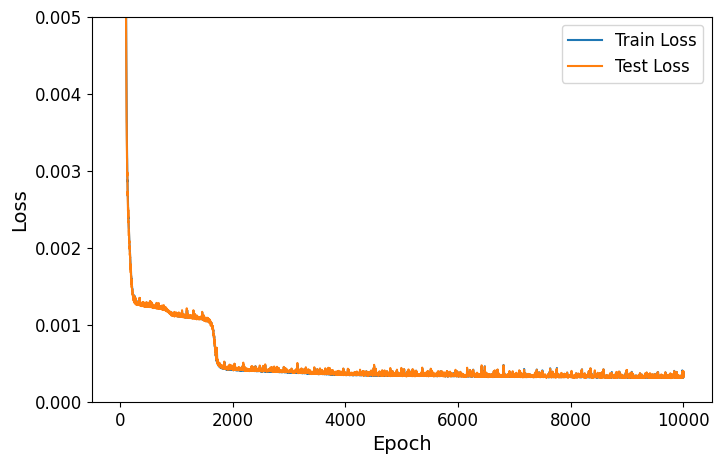

In [25]:
fig, ax = plt.subplots(1,1,figsize=[8,5])
#plt.title('Train and Test Loss over Epochs')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
epochs = range(1, num_epochs + 1)

sns.lineplot(x=epochs, y=train_losses, label='Train Loss',ax=ax)
sns.lineplot(x=epochs, y=test_losses, label='Test Loss',ax=ax)
ax.set_ylim(0, 0.005)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(fontsize=12)

200 (100, 200)


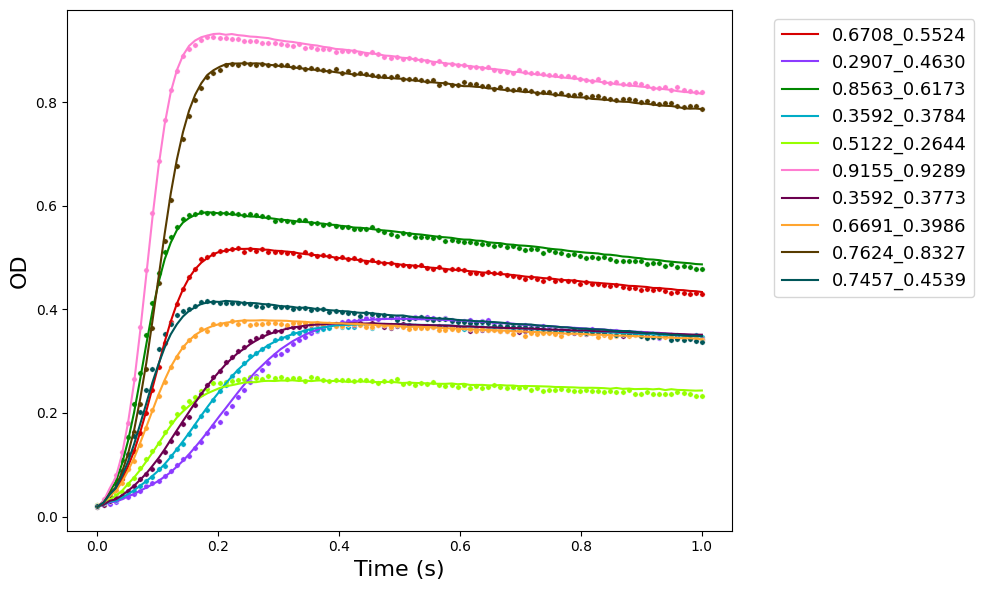

In [20]:
#Plotting the decoded vectors
fig, ax = plt.subplots(1,1,figsize=[10,6])
custom_palette=sns.color_palette(cc.glasbey,len(unique_batches))

model=trained_models[0]
print(len(batches_test),df_test.shape)        
np.random.seed(4)
random.seed(4)

# Select 1 random test curve of each type
test_indices2 = [random.choice([i for i, b in enumerate(batches_test) if b == batch]) for batch in unique_batches]
batches_test2 = [batches_test[i] for i in test_indices2]
test_data2 = df_test.iloc[:,test_indices2].copy()

#transform the subset test in a tensor, encode it and decode it
test_data2_T=test_data2.T
X_test2=test_data2_T.values
X_test_tensor2 = torch.FloatTensor(X_test2)

test_mean,test_logvar = model.encode(X_test_tensor2)
test_mean = test_mean.detach().numpy()
test_logvar = test_logvar.detach().numpy()

decoded_test2 = model.decode(torch.FloatTensor(test_mean)).detach().numpy()
decoded_test2_df=pd.DataFrame(decoded_test2).T

decoded_test2_df['Time [s]'] = t/t[-1]
test_data2['Time [s]'] = t/t[-1]
 
for column,column2,color,batch in zip(decoded_test2_df.columns.values[:len(batches_test2)],test_data2.columns.values[:len(batches_test2)], custom_palette, batches_test2):
    sns.lineplot(data=decoded_test2_df, x='Time [s]', y=column, ax=ax, color=color, label=batch)
    sns.scatterplot(data=test_data2, x='Time [s]', y=column2, ax=ax, color=color,s=15)

plt.xlabel('Time (s)', fontsize=16)
plt.ylabel('OD', fontsize=16)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 13})
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



(100, 1000) 1000


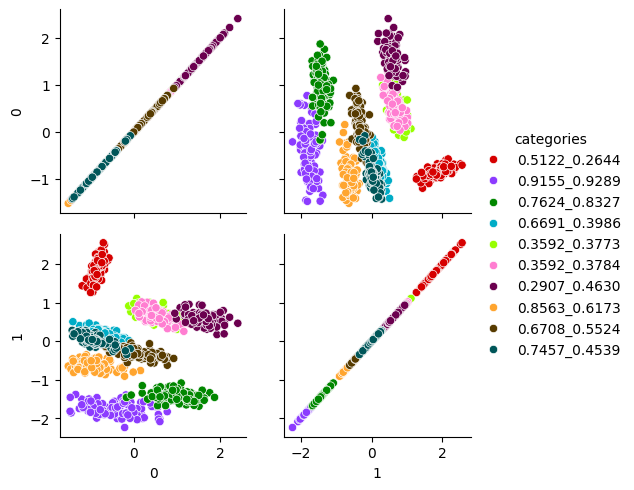

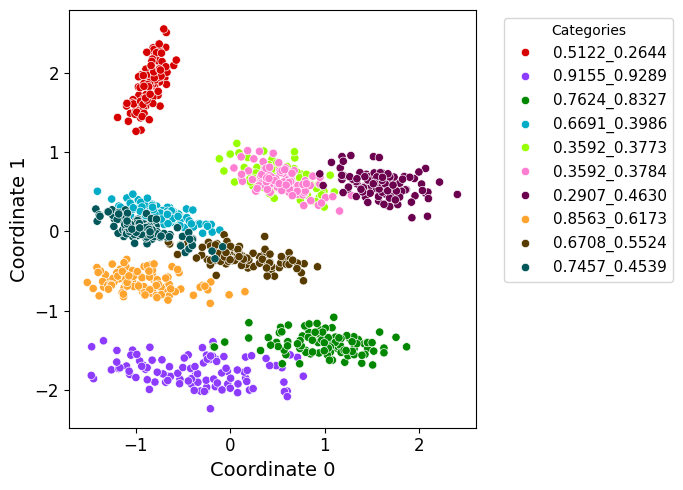

In [21]:
df_curves_T=df_curves.T
X=df_curves_T.values
X_tensor = torch.FloatTensor(X)
print(df_curves.shape,len(batches_list))

# Encoding the data using the trained autoencoder
mean,logvar = model.encode(X_tensor)
mean = mean.detach().numpy()
logvar = logvar.detach().numpy()
mean= pd.DataFrame(mean)
mean['categories']=batches_list

custom_palette=sns.color_palette(cc.glasbey,len(unique_batches)) 
g = sns.PairGrid(mean,hue='categories',palette=custom_palette)
g.map(sns.scatterplot)
g.add_legend()

x_col = g.x_vars[0]  # The x variable for the subplot at (1, 0)
y_col = g.y_vars[1]  # The y variable for the subplot at (1, 0)
data_subset = mean[[x_col, y_col, 'categories']]

# Define points
p1 = (-1.6, -1.5)
p2 = (-1.2, 0)
p3 = (-2.0, 0.4)

# Plot the extracted data in a new figure
fig, ax = plt.subplots(1,1,figsize=[7,5])
sns.scatterplot(data=data_subset, x=x_col, y=y_col, hue='categories', palette=custom_palette)

# # Add the dashed line
# x_start, x_end = -1.6, 1.40
# y_start, y_end = -1.1, 0.0
# plt.plot([x_start, x_end], [y_start, y_end], linestyle='--', color='black')

# # Function to add multiple arrows along a line
# def add_arrows(x_start, x_end, y_start, y_end, num_arrows=5, arrow_length=0.1):
#     arrowprops = dict(facecolor='black', edgecolor='black', arrowstyle='-|>', lw=1)
#     for i in np.linspace(0, 1, num_arrows, endpoint=False)[1:]:
#         x = x_start + i * (x_end - x_start)
#         y = y_start + i * (y_end - y_start)
#         dx = (x_end - x_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
#         dy = (y_end - y_start) * arrow_length / np.hypot(x_end - x_start, y_end - y_start)
#         ax.annotate('', xy=(x + dx, y + dy), xytext=(x, y), arrowprops=arrowprops)

# # Add arrows along the dashed line
# add_arrows(x_start, x_end, y_start, y_end, num_arrows=7, arrow_length=0.15)
# # Add circles at the specified points
# circle1 = plt.Circle(p1, 0.1, color='black', fill=False, linewidth=2, zorder=5)  # Adjust radius as needed
# circle2 = plt.Circle(p2, 0.1, color='black', fill=False, linewidth=2, zorder=5)
# circle3 = plt.Circle(p3, 0.1, color='black', fill=False, linewidth=2, zorder=5)
# ax.add_artist(circle1)
# ax.add_artist(circle2)
# ax.add_artist(circle3)
# plt.text(p1[0]-0.11, p1[1], 'p1', fontsize=12, color='black', ha='right')
# plt.text(p2[0]-0.11, p2[1], 'p2', fontsize=12, color='black', ha='right')
# plt.text(p3[0], p3[1]+0.15, 'p3', fontsize=12, color='black', ha='right')
# plt.text(x_start-0.02, y_start, '0', fontsize=12, color='black', ha='right')
# plt.text(x_end+0.1, y_end, '9', fontsize=12, color='black', ha='right')
# # Customize the plot

plt.xlabel('Coordinate 0', fontsize=14)
plt.ylabel('Coordinate 1', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
# ax.set_xticks(np.arange(-3.0, 2.1, 1.)) 
# ax.set_yticks(np.arange(-2.0, 1.6, 1.))
# Place the legend outside the plot
plt.legend(title='Categories', bbox_to_anchor=(1.05, 1), loc='upper left',fontsize=11)
plt.tight_layout()  # Adjust layout to make room for the legend
plt.show()



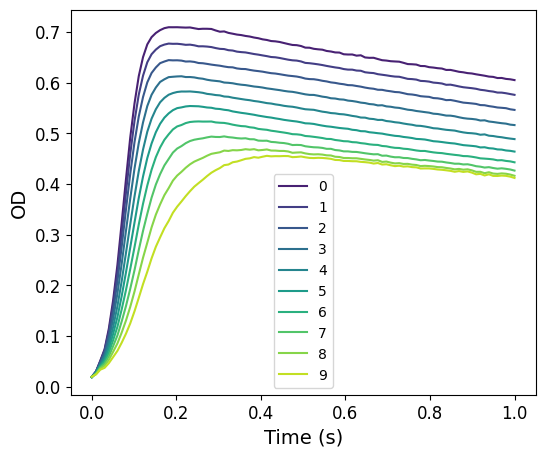

In [22]:
#Now lets see how is the form of the whole latent space to check the completeness and continuity
min_value=[-1.6, -1.1]
max_value=[1.40, 0.0]
# min_value=[-1, -2]
# max_value=[-1, 2.0]
whole_latent_space=np.linspace(min_value,max_value,num=10)     #curves from the latent space

#Decoding the data using the trained autoencoder 
whole_latent_space_df= pd.DataFrame(model.decoder(torch.FloatTensor(whole_latent_space)).detach().numpy())

#Transpose it in order to plot 
whole_latent_space_df=whole_latent_space_df.T
whole_latent_space_df['Time [s]'] = t/t[-1]

fig, ax = plt.subplots(1,1,figsize=[6,5])

#Plot the decoded vectors
custom_palette2=sns.color_palette('viridis',10)
for column, color in zip(whole_latent_space_df.columns.values[:len(whole_latent_space)], custom_palette2[:len(whole_latent_space)]):
    sns.lineplot(data=whole_latent_space_df, x='Time [s]', y=column, ax=ax, color=color, label=whole_latent_space_df.columns.values[column])

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()

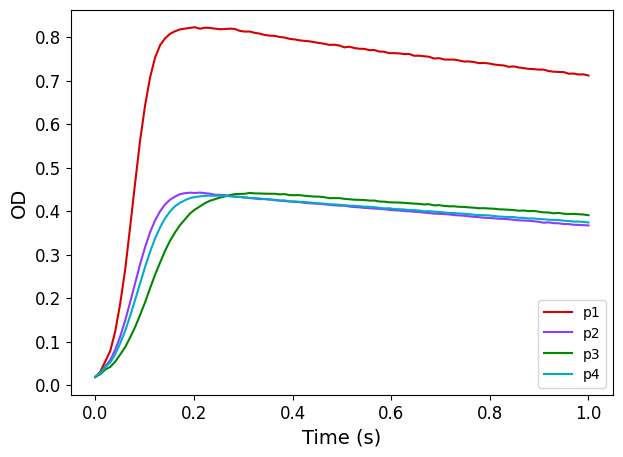

In [23]:
#Now lets see how is the form of the whole latent space to check the completeness and continuity
p1=[-1.6,-1.5]    #'LB'
p2=[-1.2, 0]    #'K2.50' 
p3=[0.5, 0]     #'K2.50'
p4=[-0.5,0]  
specific_points=[p1,p2,p3,p4]     

#Decoding the data using the trained autoencoder 
decoded_points= pd.DataFrame(model.decode(torch.FloatTensor(specific_points)).detach().numpy())

#Transpose it in order to plot 
decoded_points=decoded_points.T
new_column_names=['p1','p2','p3','p4']
decoded_points.columns=new_column_names
decoded_points['Time [s]'] = t/t[-1]

fig, ax = plt.subplots(1,1,figsize=[7,5])

#Plot the decoded vectors
palette=sns.color_palette(cc.glasbey,len(unique_batches))
for column, color in zip(decoded_points.columns.values[:len(specific_points)], palette):
    sns.lineplot(data=decoded_points, x='Time [s]', y=column, ax=ax, color=color, label=column)

plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('OD', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend()